# This is an 2D implementation of the Quickhull Algorithm in Python.

**This algorithm is used to find the convex hull of a set of points in a plane. It works by recursively dividing the point set into two subsets and finding the convex hull for each subset**

In [219]:
# Import Python Modules
import matplotlib.pyplot as plt
import math
import random

In [ ]:
# Create points for quickhull implementation
n_points = 100
points = [(random.random(), random.random()) for _ in range(n_points)]

print(points)

x = [p[0] for p in points]
y = [p[1] for p in points]


[(0.7930255077151235, 0.29219292981787004), (0.3238000372197426, 0.22929982857417552), (0.02994940195708884, 0.7219500811589055), (0.074831817575851, 0.6955091720393485), (0.8068507681054747, 0.7085053344416878), (0.22548587265931053, 0.7581931112237189), (0.8013296714817972, 0.6953826563327373), (0.6309591473027274, 0.028124110991598728), (0.7363867036847188, 0.6617876366385591), (0.632915723348939, 0.7073480978708861), (0.8282065366100214, 0.8513067013660509), (0.06949203601675413, 0.09150791671745617), (0.8093362007919719, 0.9343049782765956), (0.7473553686532102, 0.8436402931872596), (0.38687824238873025, 0.23459364841803954), (0.5537744421271314, 0.07046994457116829), (0.9534803628589709, 0.485831918034073), (0.08072964933054338, 0.8805497079793022), (0.49901583224616053, 0.10866155045347214), (0.5474604492532195, 0.09756059376894022), (0.05196474591310707, 0.6114790086006651), (0.27819127320571546, 0.8555602554108508), (0.6362426113116183, 0.09594614618985686), (0.663307719676804

In [ ]:

def perpendicular_distance(p1, p2, p):
    """
    Finds the distance from point p to the line that joins through points p1, p2. This is the determinant of the vectors

    Arguments:
        p1 -- point 1 [x1, y1]
        p2 -- point 2 [x2, y2]
        p  -- point to find distance to line [x, y]

    Return: Distance from point p to the line through p1 and p2
    """
    return (p[1] - p1[1]) * (p2[0] - p1[0]) - (p2[1] - p1[1]) * (p[0] - p1[0])
    

In [ ]:
def find_outside_points(p1, p2, points):
        """
        Finds the points that outside the convex hull.
        Arguments:
            p1 -- point 1 [x1, y1]
            p2 -- point 2 [x2, y2]
            points -- list of points [[x1, y1], [x2, y2], ...]

        Return: A list of points that are outside the convex hull.
        """
        if not points:
            return []
        farthest_point = max(points, key=lambda p: abs(perpendicular_distance(p1, p2, p)))
        #Get rightmost points
        points1 = [p for p in points if perpendicular_distance(p1, farthest_point, p) > 0]
        #Get leftmost points
        points2 = [p for p in points if perpendicular_distance(farthest_point, p2, p) > 0]
        return find_outside_points(p1, farthest_point, points1) + [farthest_point] + find_outside_points(farthest_point, p2, points2)

In [ ]:
def sort_points(points):
    """
    This sorts the convex hull points in a counter clockwise position to make sure the plot draws the convex hull accurately. This does not impact the quickhull algorithm in anyway,
    it is for visualisation on the graph
    
    Arguments:
        points - [(x1, y1), (x2, y2), ...] - The points from the convex hull
    Return: A list of points sorted in counter clockwise order
    """
    
    if len(points) <= 1:
        return points
    
    #Find the point closest to the centroid out of all the points to focus on
    centroid_x = sum(p[0] for p in points) / len(points)
    centroid_y = sum(p[1] for p in points) / len(points)

    def angle_from_centroid(point):
        #Calculating the angle between the point and the centroid, it does this for both centroid on each axis
        return math.atan2(point[1] - centroid_y, point[0] - centroid_x)
    return sorted(points, key=angle_from_centroid)

In [224]:
# Quickhull Algorithm Implementation
def quickhull(points):
    """
    Quickhull algorithm to find the convex hull of a set of points in a 2D space.
    Arguments:
        points -- list of points [(x1, y1), (x2, y2), ...]
    Return: A list of points that represent the convex hull.
    """
    
    # Base Case
    if len(points) <= 1:
        return(points)
    
    min_point = min(points)
    max_point = max(points)
    hull = find_outside_points(min_point, max_point, points) + find_outside_points(max_point, min_point, points)
    return sort_points(set(hull))
    

12
12


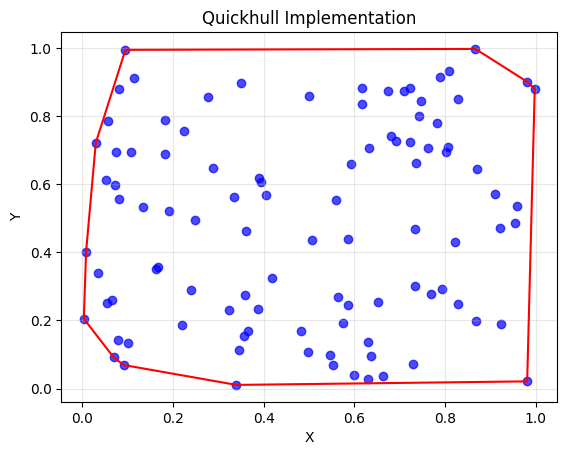

In [225]:
convex_hull = quickhull(points)
convex_x = [p[0] for p in convex_hull]
convex_y = [p[1] for p in convex_hull]
convex_x.append(convex_x[0])
convex_y.append(convex_y[0])
print(len(convex_x))
print(len(convex_y))
plt.scatter(x, y, alpha = 0.7, color = "blue")
plt.plot(convex_x, convex_y, color = "red")
plt.title("Quickhull Implementation")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha = 0.3)
plt.show()     

# Below is a 2D implementation of the Quickhull Algorithm.